# 🎨 Image Generation From Scratch (No Pretrained Models)

This notebook builds **three image generation models entirely from scratch** using pure PyTorch:

| # | Model | Description |
|---|-------|-------------|
| 1 | **DCGAN** | Deep Convolutional GAN — generates sharp images |
| 2 | **VAE** | Variational Autoencoder — learns image distribution |
| 3 | **DDPM** | Denoising Diffusion Probabilistic Model — state-of-the-art |

All trained on **MNIST** (handwritten digits). No pretrained weights used anywhere.

---

## 📦 Setup & Imports

In [1]:
!pip install torch torchvision matplotlib numpy pillow

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\BS\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import numpy as np

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ── Shared helper ──────────────────────────────────────────────────────────
def show_images(tensor, title="Generated Images", nrow=8):
    """Display a batch of images from a tensor in [-1,1] or [0,1]."""
    tensor = tensor.detach().cpu()
    if tensor.min() < 0:          # [-1,1] → [0,1]
        tensor = (tensor + 1) / 2
    tensor = tensor.clamp(0, 1)
    grid = make_grid(tensor, nrow=nrow, padding=2)
    plt.figure(figsize=(12, 12 // nrow + 2))
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
    plt.axis("off")
    plt.title(title, fontsize=14)
    plt.tight_layout()
    plt.show()

Device: cpu


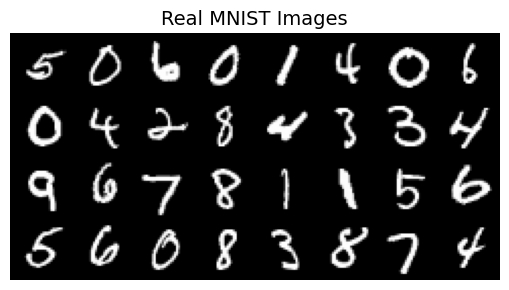

Dataset: 60000 images  |  Batches/epoch: 468


In [3]:
# ── Dataset (MNIST) ────────────────────────────────────────────────────────
BATCH_SIZE = 128
IMG_SIZE   = 28

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])   # → [-1, 1]
])

dataset    = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

# Preview real images
real_batch, _ = next(iter(dataloader))
show_images(real_batch[:32], title="Real MNIST Images")
print(f"Dataset: {len(dataset)} images  |  Batches/epoch: {len(dataloader)}")

---
# 1️⃣ DCGAN — Deep Convolutional GAN

**How it works:**
- **Generator** upsamples a random noise vector via transposed convolutions → fake image
- **Discriminator** downsamples the image via convolutions → real / fake probability
- They compete: G tries to fool D, D tries to catch G

```
noise (z) ──► [ConvTranspose2d layers] ──► fake image (28×28)
                                                  │
real image ───────────────────────────► [Conv2d layers] ──► real/fake score
```

In [4]:
LATENT_DIM = 100
NGF        = 64   # Generator feature map base size
NDF        = 64   # Discriminator feature map base size

def weights_init(m):
    """Initialize Conv and BatchNorm weights as in the original DCGAN paper."""
    cname = m.__class__.__name__
    if "Conv" in cname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in cname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


class DCGenerator(nn.Module):
    """
    Input:  (B, LATENT_DIM, 1, 1)
    Output: (B, 1, 28, 28)
    """
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # z → 7×7
            nn.ConvTranspose2d(LATENT_DIM, NGF * 4, 7, 1, 0, bias=False),
            nn.BatchNorm2d(NGF * 4),
            nn.ReLU(True),
            # 7×7 → 14×14
            nn.ConvTranspose2d(NGF * 4, NGF * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NGF * 2),
            nn.ReLU(True),
            # 14×14 → 28×28
            nn.ConvTranspose2d(NGF * 2, 1, 4, 2, 1, bias=False),
            nn.Tanh()   # output in [-1, 1]
        )

    def forward(self, z):
        return self.net(z)


class DCDiscriminator(nn.Module):
    """
    Input:  (B, 1, 28, 28)
    Output: (B, 1)  — probability of being real
    """
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # 28×28 → 14×14
            nn.Conv2d(1, NDF, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # 14×14 → 7×7
            nn.Conv2d(NDF, NDF * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NDF * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # 7×7 → 1×1
            nn.Conv2d(NDF * 2, 1, 7, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x).view(-1, 1)


dcG = DCGenerator().to(DEVICE).apply(weights_init)
dcD = DCDiscriminator().to(DEVICE).apply(weights_init)
print("Generator params:    ", sum(p.numel() for p in dcG.parameters()))
print("Discriminator params:", sum(p.numel() for p in dcD.parameters()))

Generator params:     1781504
Discriminator params: 138624


In [ ]:
# ── DCGAN Training ─────────────────────────────────────────────────────────
DCGAN_EPOCHS = 20
LR           = 0.0002

opt_G   = optim.Adam(dcG.parameters(), lr=LR, betas=(0.5, 0.999))
opt_D   = optim.Adam(dcD.parameters(), lr=LR, betas=(0.5, 0.999))
bce     = nn.BCELoss()
fixed_z = torch.randn(32, LATENT_DIM, 1, 1, device=DEVICE)

g_losses_dc, d_losses_dc = [], []

for epoch in range(DCGAN_EPOCHS):
    g_sum = d_sum = 0
    for real, _ in dataloader:
        real = real.to(DEVICE)
        bs   = real.size(0)
        ones = torch.ones(bs,  1, device=DEVICE)
        zeros= torch.zeros(bs, 1, device=DEVICE)

        # ── Train Discriminator ──────────────────────────────
        opt_D.zero_grad()
        z    = torch.randn(bs, LATENT_DIM, 1, 1, device=DEVICE)
        fake = dcG(z).detach()
        d_loss = bce(dcD(real), ones) + bce(dcD(fake), zeros)
        d_loss.backward()
        opt_D.step()

        # ── Train Generator ──────────────────────────────────
        opt_G.zero_grad()
        z    = torch.randn(bs, LATENT_DIM, 1, 1, device=DEVICE)
        fake = dcG(z)
        g_loss = bce(dcD(fake), ones)   # G wants D to say "real"
        g_loss.backward()
        opt_G.step()

        g_sum += g_loss.item()
        d_sum += d_loss.item()

    g_losses_dc.append(g_sum / len(dataloader))
    d_losses_dc.append(d_sum / len(dataloader))

    if (epoch + 1) % 5 == 0:
        print(f"[DCGAN] Epoch {epoch+1}/{DCGAN_EPOCHS}  "
            f"G: {g_losses_dc[-1]:.4f}  D: {d_losses_dc[-1]:.4f}")

print("✅ DCGAN training done!")

# Show results
dcG.eval()
with torch.no_grad():
    samples = dcG(fixed_z)
show_images(samples, title="DCGAN — Generated Digits")

# Loss curve
plt.figure(figsize=(8, 3))
plt.plot(g_losses_dc, label="G Loss")
plt.plot(d_losses_dc, label="D Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("DCGAN Training Losses"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
# 2️⃣ VAE — Variational Autoencoder

**How it works:**
- **Encoder** compresses an image to a mean (μ) and variance (σ²) in latent space
- **Reparameterization trick**: z = μ + σ·ε  (ε ~ N(0,1)) — makes it differentiable
- **Decoder** reconstructs the image from z
- Loss = Reconstruction loss + KL divergence (keeps latent space regular)

```
image ──► Encoder ──► (μ, σ) ──► z ──► Decoder ──► reconstructed image
                                  ↑
                             ε ~ N(0,1)
```

In [ ]:
LATENT_VAE = 16   # Smaller latent dim — forces tight encoding

class VAE(nn.Module):
    def __init__(self, latent_dim=LATENT_VAE):
        super().__init__()
        self.latent_dim = latent_dim

        # ── Encoder ───────────────────────────────────────────
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, 2, 1),   # 28→14
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, 2, 1),  # 14→7
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 256),
            nn.ReLU(),
        )
        self.fc_mu     = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

        # ── Decoder ───────────────────────────────────────────
        self.decoder_fc = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 64 * 7 * 7),
            nn.ReLU(),
        )
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, 2, 1),  # 7→14
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 4, 2, 1),   # 14→28
            nn.Tanh()
        )

    def encode(self, x):
        h      = self.encoder(x)
        mu     = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        """z = mu + std * epsilon  (epsilon ~ N(0,I))"""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def decode(self, z):
        h = self.decoder_fc(z)
        h = h.view(-1, 64, 7, 7)
        return self.decoder_conv(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z          = self.reparameterize(mu, logvar)
        recon      = self.decode(z)
        return recon, mu, logvar


def vae_loss(recon, x, mu, logvar, beta=1.0):
    """ELBO loss = Reconstruction + beta * KL divergence."""
    recon_loss = F.mse_loss(recon, x, reduction="sum")
    # KL: -0.5 * sum(1 + log(σ²) - μ² - σ²)
    kl_loss    = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return (recon_loss + beta * kl_loss) / x.size(0)


vae = VAE().to(DEVICE)
print("VAE params:", sum(p.numel() for p in vae.parameters()))

In [ ]:
# ── VAE Training ───────────────────────────────────────────────────────────
VAE_EPOCHS = 20
opt_vae    = optim.Adam(vae.parameters(), lr=1e-3)
vae_losses = []

for epoch in range(VAE_EPOCHS):
    total = 0
    for x, _ in dataloader:
        x = x.to(DEVICE)
        opt_vae.zero_grad()
        recon, mu, logvar = vae(x)
        loss = vae_loss(recon, x, mu, logvar)
        loss.backward()
        opt_vae.step()
        total += loss.item()

    avg = total / len(dataloader)
    vae_losses.append(avg)

    if (epoch + 1) % 5 == 0:
        print(f"[VAE] Epoch {epoch+1}/{VAE_EPOCHS}  Loss: {avg:.2f}")

print("✅ VAE training done!")

# ── Generate new images by sampling from N(0,I) ────────────────────────────
vae.eval()
with torch.no_grad():
    z       = torch.randn(32, LATENT_VAE, device=DEVICE)
    samples = vae.decode(z)
show_images(samples, title="VAE — Generated Digits (sampled from latent space)")

# ── Show reconstruction quality ─────────────────────────────────────────────
x_test, _ = next(iter(dataloader))
x_test     = x_test[:16].to(DEVICE)
with torch.no_grad():
    recon, _, _ = vae(x_test)
show_images(torch.cat([x_test, recon]), title="VAE — Top: Real | Bottom: Reconstructed", nrow=16)

plt.figure(figsize=(6, 3))
plt.plot(vae_losses)
plt.xlabel("Epoch"); plt.ylabel("ELBO Loss")
plt.title("VAE Training Loss"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
# 🔭 Latent Space Interpolation between two images
vae.eval()
x_batch, _ = next(iter(dataloader))
x_a, x_b   = x_batch[0:1].to(DEVICE), x_batch[1:2].to(DEVICE)

with torch.no_grad():
    mu_a, _ = vae.encode(x_a)
    mu_b, _ = vae.encode(x_b)

steps = 10
interps = []
for alpha in np.linspace(0, 1, steps):
    z_interp = (1 - alpha) * mu_a + alpha * mu_b
    with torch.no_grad():
        interps.append(vae.decode(z_interp))

show_images(torch.cat(interps), title="VAE Latent Space Interpolation (A → B)", nrow=steps)

---
# 3️⃣ DDPM — Denoising Diffusion Probabilistic Model

**How it works:**
- **Forward process**: gradually add Gaussian noise to a real image over T steps
- **Reverse process**: train a U-Net to predict and remove that noise step-by-step
- **Generation**: start from pure noise, repeatedly denoise using the trained U-Net

```
Real image  ──[add noise T times]──► Pure noise
Pure noise  ──[denoise T times] ──► Generated image   ← this is what we train
```

In [ ]:
# ── Noise Schedule ─────────────────────────────────────────────────────────
T          = 300          # Total diffusion steps
BETA_START = 1e-4
BETA_END   = 0.02

betas      = torch.linspace(BETA_START, BETA_END, T).to(DEVICE)
alphas     = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)        # ᾱ_t = Π_{s=1}^t α_s

def q_sample(x0, t, noise=None):
    """
    Forward diffusion: add noise to x0 at timestep t.
    q(x_t | x_0) = N(x_t; sqrt(ᾱ_t)*x_0, (1-ᾱ_t)*I)
    """
    if noise is None:
        noise = torch.randn_like(x0)
    ab_t  = alpha_bars[t].view(-1, 1, 1, 1)   # broadcast over (B,C,H,W)
    return ab_t.sqrt() * x0 + (1 - ab_t).sqrt() * noise, noise

# Visualize the forward noising process
x_demo, _ = next(iter(dataloader))
x_demo    = x_demo[0:1].to(DEVICE)
steps_viz = [0, 50, 100, 150, 200, 250, 299]

fig, axes = plt.subplots(1, len(steps_viz), figsize=(14, 2.5))
for ax, t_val in zip(axes, steps_viz):
    t_tensor = torch.tensor([t_val], device=DEVICE)
    noisy, _ = q_sample(x_demo, t_tensor)
    img = (noisy[0, 0].cpu().clamp(-1,1) + 1) / 2
    ax.imshow(img, cmap="gray")
    ax.axis("off")
    ax.set_title(f"t={t_val}", fontsize=9)
plt.suptitle("Forward Diffusion: adding noise over time", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# ── Lightweight U-Net for DDPM ──────────────────────────────────────────────
class SinusoidalTimeEmb(nn.Module):
    """Encodes timestep t into a sinusoidal embedding vector."""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half  = self.dim // 2
        freqs = torch.exp(
            -np.log(10000) * torch.arange(half, device=t.device) / half
        )
        args  = t[:, None].float() * freqs[None]
        emb   = torch.cat([args.sin(), args.cos()], dim=-1)
        return emb


class ResBlock(nn.Module):
    """Residual block conditioned on a time embedding."""
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.conv1   = nn.Conv2d(in_ch,  out_ch, 3, padding=1)
        self.conv2   = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.time_fc = nn.Linear(time_emb_dim, out_ch)
        self.norm1   = nn.GroupNorm(8, out_ch)
        self.norm2   = nn.GroupNorm(8, out_ch)
        self.skip    = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = F.silu(self.norm1(self.conv1(x)))
        h = h + self.time_fc(F.silu(t_emb))[:, :, None, None]
        h = F.silu(self.norm2(self.conv2(h)))
        return h + self.skip(x)


class UNet(nn.Module):
    """
    Tiny U-Net that predicts the noise added at step t.
    Input:  noisy image (B,1,28,28) + timestep t
    Output: predicted noise (B,1,28,28)
    """
    def __init__(self, time_emb_dim=64):
        super().__init__()
        self.time_emb = nn.Sequential(
            SinusoidalTimeEmb(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.SiLU(),
        )
        # Encoder
        self.enc1 = ResBlock(1,  32, time_emb_dim)
        self.enc2 = ResBlock(32, 64, time_emb_dim)
        self.down  = nn.AvgPool2d(2)
        # Bottleneck
        self.bot1 = ResBlock(64, 128, time_emb_dim)
        self.bot2 = ResBlock(128, 64, time_emb_dim)
        # Decoder
        self.up   = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.dec2 = ResBlock(64 + 64, 32, time_emb_dim)
        self.dec1 = ResBlock(32 + 32, 32, time_emb_dim)
        self.out  = nn.Conv2d(32, 1, 1)

    def forward(self, x, t):
        t_emb = self.time_emb(t)          # (B, time_emb_dim)
        # Encode
        e1 = self.enc1(x,  t_emb)         # (B, 32, 28, 28)
        e2 = self.enc2(self.down(e1), t_emb)  # (B, 64, 14, 14)
        # Bottleneck
        b  = self.bot1(self.down(e2), t_emb)  # (B,128,  7,  7)
        b  = self.bot2(b, t_emb)              # (B, 64,  7,  7)
        # Decode with skip connections
        d2 = self.dec2(torch.cat([self.up(b), e2], dim=1), t_emb)  # 14×14
        d1 = self.dec1(torch.cat([self.up(d2), e1], dim=1), t_emb) # 28×28
        return self.out(d1)


unet = UNet().to(DEVICE)
print("U-Net params:", sum(p.numel() for p in unet.parameters()))

In [ ]:
# ── DDPM Training ──────────────────────────────────────────────────────────
DDPM_EPOCHS = 20
opt_ddpm    = optim.Adam(unet.parameters(), lr=2e-4)
ddpm_losses = []

for epoch in range(DDPM_EPOCHS):
    total = 0
    for x0, _ in dataloader:
        x0 = x0.to(DEVICE)
        bs = x0.size(0)

        # Sample random timesteps for each image in the batch
        t = torch.randint(0, T, (bs,), device=DEVICE)

        # Add noise to images
        x_noisy, noise = q_sample(x0, t)

        # Predict the noise
        noise_pred = unet(x_noisy, t)

        # Simple MSE loss between predicted and actual noise
        loss = F.mse_loss(noise_pred, noise)

        opt_ddpm.zero_grad()
        loss.backward()
        opt_ddpm.step()
        total += loss.item()

    avg = total / len(dataloader)
    ddpm_losses.append(avg)
    if (epoch + 1) % 5 == 0:
        print(f"[DDPM] Epoch {epoch+1}/{DDPM_EPOCHS}  Loss: {avg:.4f}")

print("✅ DDPM training done!")

In [ ]:
# ── DDPM Sampling (reverse diffusion) ─────────────────────────────────────
@torch.no_grad()
def ddpm_sample(model, n_samples=16, show_steps=False):
    """
    Start from pure noise and iteratively denoise.
    p(x_{t-1}|x_t) = N(x_{t-1}; mu_theta(x_t, t), sigma_t^2 * I)
    """
    model.eval()
    x = torch.randn(n_samples, 1, IMG_SIZE, IMG_SIZE, device=DEVICE)
    snapshots = []

    for t_val in reversed(range(T)):
        t_batch = torch.full((n_samples,), t_val, device=DEVICE, dtype=torch.long)

        noise_pred = model(x, t_batch)

        # Compute reverse-process mean
        alpha_t    = alphas[t_val]
        alpha_bar_t= alpha_bars[t_val]
        beta_t     = betas[t_val]

        mean = (1 / alpha_t.sqrt()) * (
            x - (beta_t / (1 - alpha_bar_t).sqrt()) * noise_pred
        )

        if t_val > 0:
            noise  = torch.randn_like(x)
            sigma  = beta_t.sqrt()
            x      = mean + sigma * noise
        else:
            x = mean   # final step: no noise added

        if show_steps and t_val in [250, 200, 150, 100, 50, 0]:
            snapshots.append((t_val, x.clone()))

    if show_steps:
        fig, axes = plt.subplots(1, len(snapshots), figsize=(14, 2.5))
        for ax, (t_val, imgs) in zip(axes, snapshots):
            grid = make_grid(((imgs[:4]+1)/2).clamp(0,1), nrow=2)
            ax.imshow(grid.cpu().permute(1,2,0).squeeze(), cmap="gray")
            ax.axis("off")
            ax.set_title(f"t={t_val}", fontsize=9)
        plt.suptitle("DDPM Reverse Diffusion: denoising over time", fontsize=12)
        plt.tight_layout(); plt.show()

    return x


# Show denoising progression
_ = ddpm_sample(unet, n_samples=16, show_steps=True)

# Show final generated images
samples = ddpm_sample(unet, n_samples=32)
show_images(samples, title="DDPM — Generated Digits")

plt.figure(figsize=(6, 3))
plt.plot(ddpm_losses)
plt.xlabel("Epoch"); plt.ylabel("MSE Loss")
plt.title("DDPM Training Loss"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
## 💾 Save All Models

In [ ]:
torch.save(dcG.state_dict(),  "dcgan_generator.pth")
torch.save(dcD.state_dict(),  "dcgan_discriminator.pth")
torch.save(vae.state_dict(),  "vae.pth")
torch.save(unet.state_dict(), "ddpm_unet.pth")
print("✅ All models saved.")

# ── Reload example ──────────────────────────────────────────────────────────
# dcG_new = DCGenerator().to(DEVICE)
# dcG_new.load_state_dict(torch.load("dcgan_generator.pth"))
# dcG_new.eval()

---
## 📊 Summary

| Model | Architecture | Loss | Strengths | Weaknesses |
|-------|-------------|------|-----------|------------|
| **DCGAN** | Generator + Discriminator | Adversarial (BCE) | Sharp images, fast sampling | Training instability (mode collapse) |
| **VAE** | Encoder + Decoder | Recon + KL divergence | Smooth latent space, interpolation | Slightly blurry outputs |
| **DDPM** | U-Net (noise predictor) | MSE on noise | High quality, stable training | Slow sampling (T steps needed) |

### 🚀 Next Steps
- Train on **CIFAR-10** or your own image dataset for color images
- Add **class conditioning** to control which digit is generated
- Speed up DDPM sampling with **DDIM** (fewer steps)
- Scale up with a larger U-Net for higher resolution images